# 협상 에이전트 실험 최종 분석
**지표**: 타결 성공률 / 규정 준수율 / 전략 일관성 / SVI 주관적 만족도

In [1]:
import os, sys, json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import kruskal, permutation_test, fisher_exact, chi2_contingency, spearmanr
from scipy.stats import gaussian_kde
from itertools import combinations
import firebase_admin
from firebase_admin import credentials, firestore

ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
print('환경 설정 완료')

환경 설정 완료


In [2]:
# ── 상수 ──────────────────────────────────────────────────────
MODE_MAP = {
    'baseline':              'pure_llm',
    'cot_previous':          'llm_rag',
    'cot_upgrade':           'llm_rag_nego_strategy',
    'pure_llm':              'pure_llm',
    'llm_rag':               'llm_rag',
    'llm_rag_nego_strategy': 'llm_rag_nego_strategy',
}

MODES = ['pure_llm', 'llm_rag', 'llm_rag_nego_strategy']

MODE_LABEL = {
    'pure_llm':              '조건 A (Pure LLM)',
    'llm_rag':               '조건 B (LLM+RAG)',
    'llm_rag_nego_strategy': '조건 C (제안 모델)',
}

MODE_SHORT = {'pure_llm': 'A', 'llm_rag': 'B', 'llm_rag_nego_strategy': 'C'}

DROP_IDS = ['e3eeb671_20260623_070851', '1ad96578_20260623_072117']

# Nash 교섭 해
NASH_B, NASH_S   = 85.0, 50.0
NASH_PRODUCT     = NASH_B * NASH_S          # 4250
NASH_THRESHOLD   = 0.6                      # 타결 성공 기준

# 파레토 프론티어
FRONTIER = [(5,100),(15,90),(45,75),(55,65),(85,50),(95,40),(100,10)]

print('상수 설정 완료')

상수 설정 완료


## 1. 데이터 로드

In [3]:
# ── Firebase ──────────────────────────────────────────────────
if not firebase_admin._apps:
    key_path = os.path.join(ROOT, 'serviceAccountKey.json')
    firebase_admin.initialize_app(credentials.Certificate(key_path))

db   = firestore.client()
docs = db.collection('negotiation_results').stream()
raw  = [doc.to_dict() for doc in docs]
print(f'Firebase 로드: {len(raw)}개')

Firebase 로드: 27개


In [4]:
# ── 데이터프레임 변환 ──────────────────────────────────────────
rows = []
for r in raw:
    mode = MODE_MAP.get(r.get('mode',''), r.get('mode',''))
    rows.append({
        'session_id':    r.get('session_id'),
        'mode':          mode,
        'human_role':    r.get('human_role'),
        'buyer_points':  float(r.get('buyer_points',  0) or 0),
        'seller_points': float(r.get('seller_points', 0) or 0),
        'survey_results':r.get('survey_results', {}),
        'timestamp':     r.get('timestamp'),
    })

df = pd.DataFrame(rows)
df = df[df['session_id'].notna()]
df = df[~df['session_id'].isin(DROP_IDS)].reset_index(drop=True)
print(f'유효 세션: {len(df)}개 (8명 × 3조건)')
print(df['mode'].value_counts().to_string())

유효 세션: 24개 (8명 × 3조건)
mode
pure_llm                 8
llm_rag_nego_strategy    8
llm_rag                  8


In [5]:
# ── CSV 로드 (LLM-as-Judge 결과) ──────────────────────────────
comp_df    = pd.read_csv('compliance_scores.csv')          # 규정 준수율 (턴별)
consist_df = pd.read_csv('consistency_scores_holistic.csv') # 전략 일관성 (세션별)
print(f'규정 준수율 CSV: {len(comp_df)}턴')
print(f'전략 일관성 CSV: {len(consist_df)}세션')

규정 준수율 CSV: 173턴
전략 일관성 CSV: 24세션


## 2. 지표 계산

In [6]:
# ── ① 타결 성공률 (Nash 효율 ≥ 60%) ──────────────────────────
df['nash_efficiency'] = (df['buyer_points'] * df['seller_points']) / NASH_PRODUCT
df['is_success']      = df['nash_efficiency'] >= NASH_THRESHOLD

# ── ② 규정 준수율 (세션별 평균) ───────────────────────────────
comp_session = (comp_df.groupby('session_id')['score']
                .mean().rename('compliance_rate').reset_index())
df = df.merge(comp_session, on='session_id', how='left')

# ── ③ 전략 일관성 (holistic 세션별 점수) ─────────────────────
consist_df['score'] = pd.to_numeric(consist_df['score'], errors='coerce')

# ── ④ SVI 설문 파싱 ───────────────────────────────────────────
svi_rows = []
for _, row in df.iterrows():
    s = row.get('survey_results') or {}
    if not s:
        continue
    svi_rows.append({
        'session_id':   row['session_id'],
        'mode':         row['mode'],
        'nash_efficiency': row['nash_efficiency'],
        'satisfaction': s.get('satisfaction'),
        'fairness':     s.get('fairness'),
        'trust':        s.get('trust'),
        'willingness':  s.get('willingness'),
    })

svi_df = pd.DataFrame(svi_rows)
svi_df[['satisfaction','fairness','trust','willingness']] = \
    svi_df[['satisfaction','fairness','trust','willingness']].apply(pd.to_numeric, errors='coerce')
svi_df['svi_total'] = svi_df[['satisfaction','fairness','trust','willingness']].mean(axis=1)

print('지표 계산 완료')
print(f'SVI 응답 세션: {len(svi_df)}개')

지표 계산 완료
SVI 응답 세션: 24개


## 3. 기술 통계

In [7]:
print('=' * 62)
print('기술 통계 요약')
print('=' * 62)

# 타결 성공률
succ_stat = df.groupby('mode')['is_success'].agg(
    성공수='sum', 전체='count',
    성공률=lambda x: f"{x.mean()*100:.1f}%"
)
print('\n[타결 성공률] (Nash 효율 ≥ 60%)')
print(succ_stat.reindex(MODES).to_string())

# Nash 효율
nash_stat = df.groupby('mode')['nash_efficiency'].agg(
    평균=lambda x: f"{x.mean()*100:.1f}%",
    SD=lambda x:   f"{x.std()*100:.1f}%",
)
print('\n[Nash 효율]')
print(nash_stat.reindex(MODES).to_string())

# 규정 준수율
comp_stat = df.groupby('mode')['compliance_rate'].agg(
    평균=lambda x: f"{x.mean()*100:.1f}%",
    SD=lambda x:   f"{x.std()*100:.1f}%",
)
print('\n[규정 준수율]')
print(comp_stat.reindex(MODES).to_string())

# 전략 일관성
cons_stat = consist_df.groupby('mode')['score'].agg(
    평균=lambda x: f"{x.mean():.2f}",
    SD=lambda x:   f"{x.std():.2f}",
)
print('\n[전략 일관성] (1~5점)')
print(cons_stat.reindex(MODES).to_string())

# SVI
SVI_DIMS = ['satisfaction','fairness','trust','willingness','svi_total']
DIM_KR   = {'satisfaction':'결과만족','fairness':'과정공정','trust':'신뢰','willingness':'재거래의사','svi_total':'SVI종합'}
print('\n[SVI 주관적 만족도] (1~7점)')
for d in SVI_DIMS:
    row = svi_df.groupby('mode')[d].agg(['mean','std']).reindex(MODES)
    vals = '  '.join(f"{MODE_SHORT[m]}={row.loc[m,'mean']:.2f}(±{row.loc[m,'std']:.2f})" for m in MODES)
    print(f"  {DIM_KR[d]}: {vals}")

기술 통계 요약

[타결 성공률] (Nash 효율 ≥ 60%)
                       성공수  전체    성공률
mode                                 
pure_llm                 6   8  75.0%
llm_rag                  4   8  50.0%
llm_rag_nego_strategy    5   8  62.5%

[Nash 효율]
                          평균     SD
mode                               
pure_llm               63.7%  21.1%
llm_rag                46.0%  33.1%
llm_rag_nego_strategy  55.5%  27.4%

[규정 준수율]
                          평균     SD
mode                               
pure_llm                0.0%   0.0%
llm_rag                56.8%  30.1%
llm_rag_nego_strategy  30.5%  18.8%

[전략 일관성] (1~5점)
                         평균    SD
mode                             
pure_llm               4.75  0.46
llm_rag                4.62  0.74
llm_rag_nego_strategy  4.62  0.52

[SVI 주관적 만족도] (1~7점)
  결과만족: A=5.88(±0.99)  B=5.00(±1.85)  C=4.38(±2.00)
  과정공정: A=5.62(±1.41)  B=4.75(±1.67)  C=4.00(±2.20)
  신뢰: A=4.75(±1.28)  B=4.50(±1.93)  C=4.00(±2.14)
  재거래의사: A=4.75(±1.83)  B=3.38(

## 4. 통계 검정

In [8]:
# ── 공통 함수 ─────────────────────────────────────────────────
PAIRS   = list(combinations(MODES, 2))
N_PAIRS = len(PAIRS)  # 3

def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    n = len(x) * len(y)
    d = (sum(xi > yi for xi in x for yi in y) -
         sum(xi < yi for xi in x for yi in y)) / n
    mag = ('large'  if abs(d)>=0.474 else
           'medium' if abs(d)>=0.330 else
           'small'  if abs(d)>=0.147 else 'negligible')
    return d, mag

def perm_p(x, y, n_resamples=9999):
    def stat(a, b, axis): return np.mean(a,axis=axis) - np.mean(b,axis=axis)
    return permutation_test((np.array(x), np.array(y)), stat,
                            n_resamples=n_resamples, alternative='two-sided').pvalue

def sig_stars(p):
    return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

def print_section(title):
    print(f'\n{"="*60}')
    print(f'  {title}')
    print(f'{"="*60}')

def run_kw_perm(groups, label):
    """Kruskal-Wallis + Pairwise Permutation + Cliff's δ"""
    print_section(label)
    vals = [groups[m] for m in MODES]
    h, p = kruskal(*vals)
    print(f'Kruskal-Wallis: H={h:.3f}, p={p:.4f} {sig_stars(p)}')
    print(f'평균: {"  ".join(f"{MODE_SHORT[m]}={groups[m].mean():.3f}" for m in MODES)}')
    print(f'SD:   {"  ".join(f"{MODE_SHORT[m]}={groups[m].std():.3f}"  for m in MODES)}')
    print(f'\nPairwise (Bonferroni α={0.05/N_PAIRS:.3f}):')
    for a, b in PAIRS:
        p_raw = perm_p(groups[a], groups[b])
        p_cor = min(p_raw * N_PAIRS, 1.0)
        d, mag = cliffs_delta(groups[a], groups[b])
        print(f"  {MODE_SHORT[a]} vs {MODE_SHORT[b]}: "
              f"p={p_raw:.4f} (Bonferroni p={p_cor:.4f} {sig_stars(p_cor)})  "
              f"Cliff's δ={d:.2f} [{mag}]")

print('함수 정의 완료')

함수 정의 완료


In [9]:
# ── ① 타결 성공률: Fisher's Exact + Odds Ratio ───────────────
print_section('① 타결 성공률 | Fisher\'s Exact + Odds Ratio')

succ = {m: df[df['mode']==m]['is_success'].values.astype(bool) for m in MODES}
table_3x2 = np.array([[s.sum(), (~s).sum()] for s in succ.values()])
chi2_val, p_chi2, _, _ = chi2_contingency(table_3x2, correction=False)
print(f'Chi-square (전체): χ²={chi2_val:.3f}, p={p_chi2:.4f} {sig_stars(p_chi2)}')
print(f'성공률: {"  ".join(f"{MODE_SHORT[m]}={succ[m].mean()*100:.1f}%" for m in MODES)}')

print(f'\nPairwise Fisher\'s Exact (Bonferroni α={0.05/N_PAIRS:.3f}):')
for a, b in PAIRS:
    t = np.array([[succ[a].sum(), (~succ[a]).sum()],
                  [succ[b].sum(), (~succ[b]).sum()]])
    OR, p_raw = fisher_exact(t)
    p_cor = min(p_raw * N_PAIRS, 1.0)
    print(f"  {MODE_SHORT[a]} vs {MODE_SHORT[b]}: "
          f"p={p_raw:.4f} (Bonferroni p={p_cor:.4f} {sig_stars(p_cor)})  "
          f"OR={OR:.2f}")


  ① 타결 성공률 | Fisher's Exact + Odds Ratio
Chi-square (전체): χ²=1.067, p=0.5866 ns
성공률: A=75.0%  B=50.0%  C=62.5%

Pairwise Fisher's Exact (Bonferroni α=0.017):
  A vs B: p=0.6084 (Bonferroni p=1.0000 ns)  OR=3.00
  A vs C: p=1.0000 (Bonferroni p=1.0000 ns)  OR=1.80
  B vs C: p=1.0000 (Bonferroni p=1.0000 ns)  OR=0.60


In [10]:
# ── ① Nash 효율 (연속값) ─────────────────────────────────────
nash_g = {m: df[df['mode']==m]['nash_efficiency'].values for m in MODES}
run_kw_perm(nash_g, '① Nash 효율 | KW + Permutation + Cliff\'s δ')


  ① Nash 효율 | KW + Permutation + Cliff's δ
Kruskal-Wallis: H=1.561, p=0.4581 ns
평균: A=0.637  B=0.460  C=0.555
SD:   A=0.197  B=0.310  C=0.256

Pairwise (Bonferroni α=0.017):
  A vs B: p=0.1962 (Bonferroni p=0.5886 ns)  Cliff's δ=0.34 [medium]
  A vs C: p=0.4890 (Bonferroni p=1.0000 ns)  Cliff's δ=0.22 [small]
  B vs C: p=0.5108 (Bonferroni p=1.0000 ns)  Cliff's δ=-0.19 [small]


In [11]:
# ── ② 규정 준수율 ─────────────────────────────────────────────
comp_g = {m: df[df['mode']==m]['compliance_rate'].dropna().values for m in MODES}
run_kw_perm(comp_g, '② 규정 준수율 | KW + Permutation + Cliff\'s δ')


  ② 규정 준수율 | KW + Permutation + Cliff's δ
Kruskal-Wallis: H=16.063, p=0.0003 ***
평균: A=0.000  B=0.568  C=0.305
SD:   A=0.000  B=0.282  C=0.176

Pairwise (Bonferroni α=0.017):
  A vs B: p=0.0004 (Bonferroni p=0.0012 **)  Cliff's δ=-1.00 [large]
  A vs C: p=0.0014 (Bonferroni p=0.0042 **)  Cliff's δ=-0.88 [large]
  B vs C: p=0.0572 (Bonferroni p=0.1716 ns)  Cliff's δ=0.52 [large]


In [12]:
# ── ③ 전략 일관성 ─────────────────────────────────────────────
cons_g = {m: consist_df[consist_df['mode']==m]['score'].dropna().values for m in MODES}
run_kw_perm(cons_g, '③ 전략 일관성 | KW + Permutation + Cliff\'s δ')


  ③ 전략 일관성 | KW + Permutation + Cliff's δ
Kruskal-Wallis: H=0.276, p=0.8712 ns
평균: A=4.750  B=4.625  C=4.625
SD:   A=0.433  B=0.696  C=0.484

Pairwise (Bonferroni α=0.017):
  A vs B: p=0.9910 (Bonferroni p=1.0000 ns)  Cliff's δ=0.03 [negligible]
  A vs C: p=0.9844 (Bonferroni p=1.0000 ns)  Cliff's δ=0.12 [negligible]
  B vs C: p=1.0000 (Bonferroni p=1.0000 ns)  Cliff's δ=0.08 [negligible]


In [13]:
# ── ④ SVI 주관적 만족도 ───────────────────────────────────────
DIM_LABEL = {
    'satisfaction': '결과만족 (Instrumental)',
    'fairness':     '과정공정 (Process)',
    'trust':        '신뢰 (Relation-1)',
    'willingness':  '재거래의사 (Relation-2)',
    'svi_total':    'SVI 종합',
}

for dim in ['satisfaction','fairness','trust','willingness','svi_total']:
    svi_g = {m: svi_df[svi_df['mode']==m][dim].dropna().values for m in MODES}
    if any(len(v)<2 for v in svi_g.values()):
        continue
    run_kw_perm(svi_g, f'④ SVI — {DIM_LABEL[dim]}')


  ④ SVI — 결과만족 (Instrumental)
Kruskal-Wallis: H=2.175, p=0.3371 ns
평균: A=5.875  B=5.000  C=4.375
SD:   A=0.927  B=1.732  C=1.867

Pairwise (Bonferroni α=0.017):
  A vs B: p=0.3406 (Bonferroni p=1.0000 ns)  Cliff's δ=0.25 [small]
  A vs C: p=0.1078 (Bonferroni p=0.3234 ns)  Cliff's δ=0.42 [medium]
  B vs C: p=0.6158 (Bonferroni p=1.0000 ns)  Cliff's δ=0.17 [small]

  ④ SVI — 과정공정 (Process)
Kruskal-Wallis: H=2.566, p=0.2772 ns
평균: A=5.625  B=4.750  C=4.000
SD:   A=1.317  B=1.561  C=2.062

Pairwise (Bonferroni α=0.017):
  A vs B: p=0.3358 (Bonferroni p=1.0000 ns)  Cliff's δ=0.30 [small]
  A vs C: p=0.1400 (Bonferroni p=0.4200 ns)  Cliff's δ=0.42 [medium]
  B vs C: p=0.5174 (Bonferroni p=1.0000 ns)  Cliff's δ=0.25 [small]

  ④ SVI — 신뢰 (Relation-1)
Kruskal-Wallis: H=0.687, p=0.7092 ns
평균: A=4.750  B=4.500  C=4.000
SD:   A=1.199  B=1.803  C=2.000

Pairwise (Bonferroni α=0.017):
  A vs B: p=0.8896 (Bonferroni p=1.0000 ns)  Cliff's δ=0.03 [negligible]
  A vs C: p=0.4870 (Bonferroni p=1.0000 

In [14]:
# ── Nash 효율 × SVI 상관 ──────────────────────────────────────
print_section('Nash 효율 × SVI 종합 Spearman 상관')
r, p_r = spearmanr(svi_df['nash_efficiency'], svi_df['svi_total'])
print(f'Spearman r={r:.3f}, p={p_r:.4f} {sig_stars(p_r)}')


  Nash 효율 × SVI 종합 Spearman 상관
Spearman r=0.148, p=0.4898 ns


## 5. 시각화

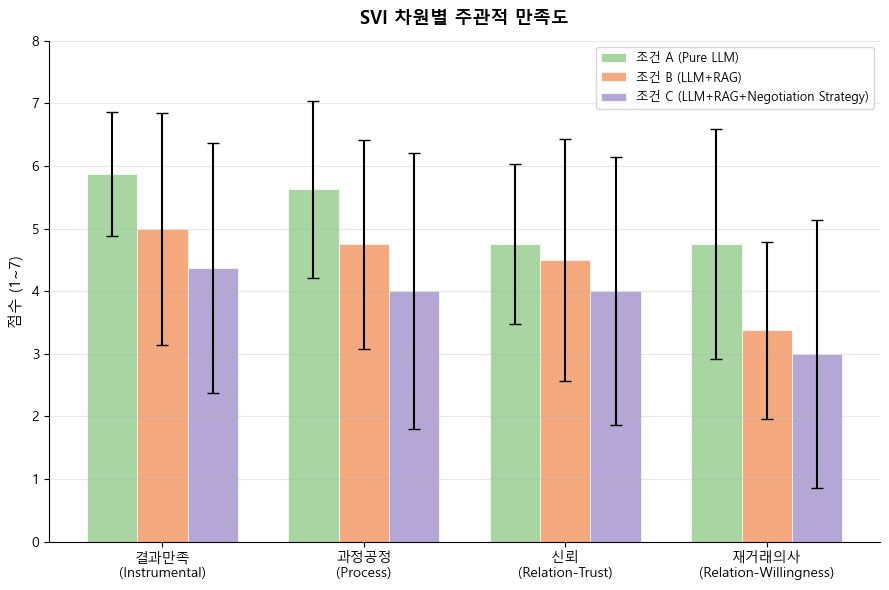

저장: images/svi_dimensions.png


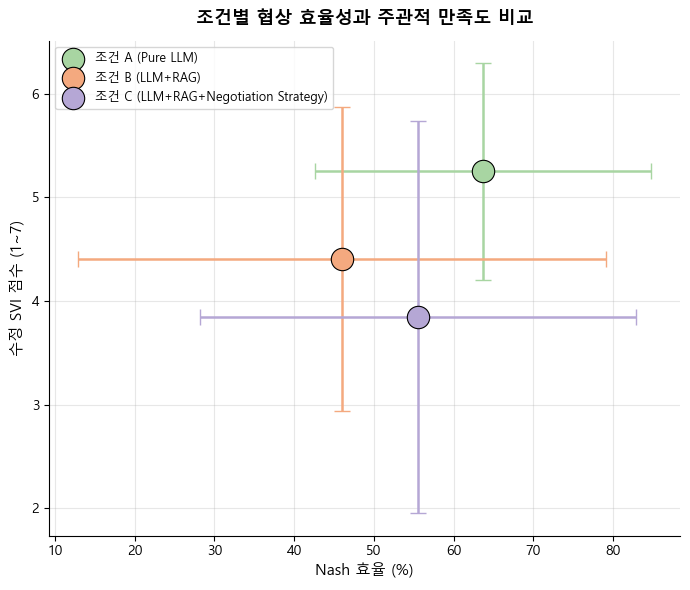

저장: images/nash_vs_svi.png


In [15]:
# ── SVI 차원별 막대 + Nash 효율 vs SVI 산점도 ─────────────────
MODE_COLORS = {
    'pure_llm':              '#A8D5A2',
    'llm_rag':               '#F4A97F',
    'llm_rag_nego_strategy': '#B5A7D5',
}

MODE_LABEL_GRAPH = {
    'pure_llm':              '조건 A (Pure LLM)',
    'llm_rag':               '조건 B (LLM+RAG)',
    'llm_rag_nego_strategy': '조건 C (LLM+RAG+Negotiation Strategy)',
}

os.makedirs('images', exist_ok=True)

# ── 그래프 1: SVI 차원별 막대 ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

dims  = ['satisfaction', 'fairness', 'trust', 'willingness']
dk    = ['결과만족\n(Instrumental)', '과정공정\n(Process)', '신뢰\n(Relation-Trust)', '재거래의사\n(Relation-Willingness)']
x     = np.arange(len(dims))
width = 0.25

for i, mode in enumerate(MODES):
    vals = [svi_df[svi_df['mode']==mode][d].mean() for d in dims]
    errs = [svi_df[svi_df['mode']==mode][d].std()  for d in dims]
    ax.bar(x + i*width, vals, width, yerr=errs, capsize=4,
           label=MODE_LABEL_GRAPH[mode], color=MODE_COLORS[mode], edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels(dk, fontsize=10)
ax.set_ylim(0, 8)
ax.set_ylabel('점수 (1~7)', fontsize=11)
ax.set_title('SVI 차원별 주관적 만족도', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/svi_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()
print('저장: images/svi_dimensions.png')

# ── 그래프 2: Nash 효율 vs SVI 종합 산점도 ───────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for mode in MODES:
    sub = svi_df[svi_df['mode']==mode]
    px  = sub['nash_efficiency'] * 100
    py  = sub['svi_total']
    ax.scatter(px.mean(), py.mean(), s=260, color=MODE_COLORS[mode],
               label=MODE_LABEL_GRAPH[mode], zorder=5, edgecolors='black', lw=0.8)
    ax.errorbar(px.mean(), py.mean(), xerr=px.std(), yerr=py.std(),
                fmt='none', color=MODE_COLORS[mode], capsize=6, lw=1.8)

ax.set_xlabel('Nash 효율 (%)', fontsize=11)
ax.set_ylabel('수정 SVI 점수 (1~7)', fontsize=11)
ax.set_title('조건별 협상 효율성과 주관적 만족도 비교', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/nash_vs_svi.png', dpi=300, bbox_inches='tight')
plt.show()
print('저장: images/nash_vs_svi.png')

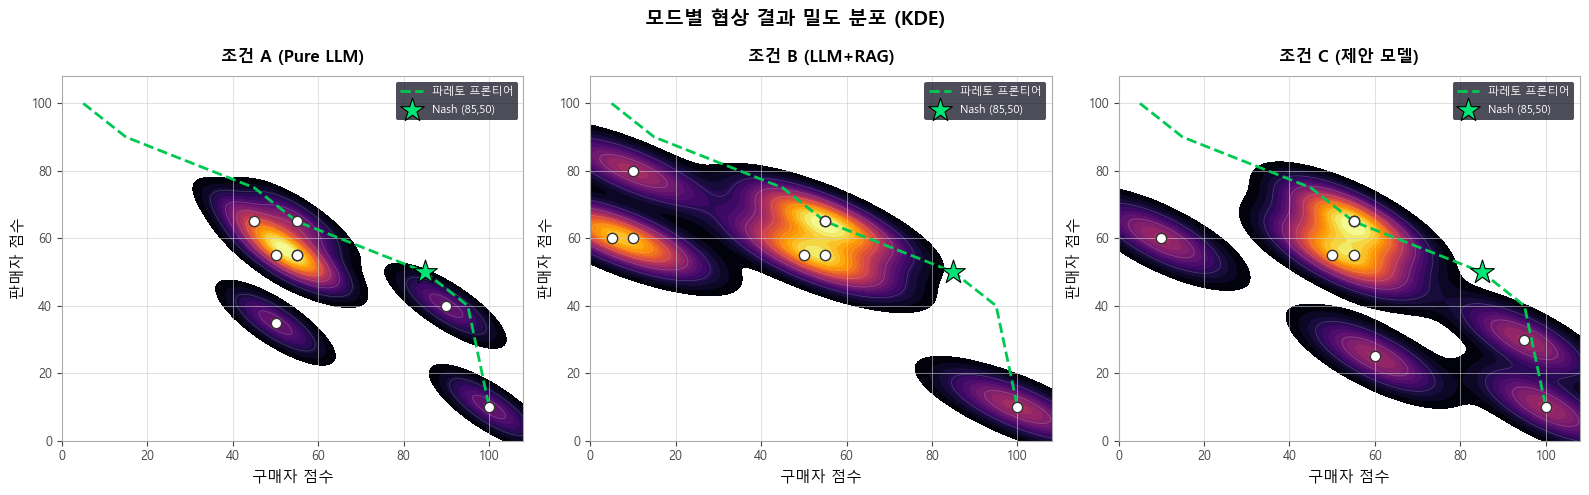

In [16]:
# ── 파레토 KDE 밀도 분포 ──────────────────────────────────────
from scipy.stats import gaussian_kde

FRONTIER_X = [p[0] for p in FRONTIER]
FRONTIER_Y = [p[1] for p in FRONTIER]

KDE_COLORS = {
    'pure_llm':              '#1565C0',
    'llm_rag':               '#2E7D32',
    'llm_rag_nego_strategy': '#B71C1C',
}

x_grid = np.linspace(0, 110, 300)
y_grid = np.linspace(0, 110, 300)
X, Y   = np.meshgrid(x_grid, y_grid)
pos    = np.vstack([X.ravel(), Y.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')

for ax, mode in zip(axes, MODES):
    sub = df[df['mode']==mode]
    bx  = sub['buyer_points'].values.astype(float)
    by  = sub['seller_points'].values.astype(float)

    ax.set_facecolor('white')
    ax.grid(True, color='#cccccc', linewidth=0.7, alpha=0.6, zorder=0)
    for spine in ax.spines.values():
        spine.set_color('#aaaaaa')
        spine.set_linewidth(0.8)

    kernel = gaussian_kde(np.vstack([bx, by]), bw_method=0.35)
    Z      = kernel(pos).reshape(X.shape)
    levels = np.linspace(Z.max() * 0.05, Z.max(), 25)

    ax.contourf(X, Y, Z, levels=levels, cmap='inferno', zorder=1, extend='neither')
    ax.contour(X, Y, Z, levels=6, colors='white', alpha=0.2, linewidths=0.5, zorder=2)

    ax.plot(FRONTIER_X, FRONTIER_Y, '--', color='#00C853', lw=2, zorder=5,
            label='파레토 프론티어')
    ax.scatter([NASH_B], [NASH_S], marker='*', s=320, color='#00E676',
               edgecolors='black', lw=0.8, zorder=10, label=f'Nash ({int(NASH_B)},{int(NASH_S)})')
    ax.scatter(bx, by, s=55, facecolors='white', edgecolors='#333333', lw=1, zorder=9)

    ax.set_xlim(0, 108)
    ax.set_ylim(0, 108)
    ax.set_xlabel('구매자 점수', fontsize=11)
    ax.set_ylabel('판매자 점수', fontsize=11)
    ax.set_title(MODE_LABEL[mode], fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors='#444444', labelsize=9)
    ax.legend(fontsize=8, loc='upper right',
              facecolor='#111122', labelcolor='white',
              framealpha=0.75, edgecolor='none')

plt.suptitle('모드별 협상 결과 밀도 분포 (KDE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/pareto_kde.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. 추가 분석
### 가설 2: 과잉 양보 가설 — Pure LLM의 높은 만족도 원인
### 가설 3: 협상 결과 통제 후 조건 간 만족도 비교

In [17]:
# ── 가설 2: 과잉 양보 가설 ────────────────────────────────────
print_section('가설 2: Pure LLM 과잉 양보 가설')

# df + svi_df 통합
merged = svi_df.merge(
    df[['session_id','mode','buyer_points','seller_points',
        'compliance_rate','is_success','nash_efficiency']],
    on=['session_id','mode']
)

# 1) 전액 환불 수준 비율 (buyer_points ≥ 80)
merged['full_refund'] = merged['buyer_points'] >= 80
print('\n[전액 환불 수준 달성 비율] (buyer_points ≥ 80, 규정상 의무 없음)')
fr = merged.groupby('mode')['full_refund'].agg(['sum','count','mean'])
fr['비율(%)'] = (fr['mean'] * 100).round(1)
print(fr[['sum','count','비율(%)']].reindex(MODES).to_string())

# 2) 규정 준수율 ↔ 구매자 점수 상관
r1, p1 = spearmanr(merged['compliance_rate'], merged['buyer_points'])
print(f'\n규정 준수율 × 구매자 획득점수:    r={r1:.3f}, p={p1:.4f} {sig_stars(p1)}')

# 3) 규정 준수율 ↔ 만족도
r2, p2 = spearmanr(merged['compliance_rate'], merged['satisfaction'])
r3, p3 = spearmanr(merged['compliance_rate'], merged['svi_total'])
print(f'규정 준수율 × 결과만족(Instrumental): r={r2:.3f}, p={p2:.4f} {sig_stars(p2)}')
print(f'규정 준수율 × SVI 종합:               r={r3:.3f}, p={p3:.4f} {sig_stars(p3)}')

# 4) 구매자 점수 ↔ 만족도 (핵심: 많이 얻을수록 만족하나?)
r4, p4 = spearmanr(merged['buyer_points'], merged['satisfaction'])
r5, p5 = spearmanr(merged['buyer_points'], merged['svi_total'])
print(f'\n구매자 획득점수 × 결과만족(Instrumental): r={r4:.3f}, p={p4:.4f} {sig_stars(p4)}')
print(f'구매자 획득점수 × SVI 종합:               r={r5:.3f}, p={p5:.4f} {sig_stars(p5)}')

print('\n▶ 해석 기준:')
print('  규정 준수율 ↑ → 구매자 점수 ↓ → SVI ↓  이면')
print('  "Pure LLM 高만족 = 규정 위반 과잉 양보의 산물" 확인됨')


  가설 2: Pure LLM 과잉 양보 가설

[전액 환불 수준 달성 비율] (buyer_points ≥ 80, 규정상 의무 없음)
                       sum  count  비율(%)
mode                                    
pure_llm                 2      8   25.0
llm_rag                  1      8   12.5
llm_rag_nego_strategy    2      8   25.0

규정 준수율 × 구매자 획득점수:    r=-0.097, p=0.6536 ns
규정 준수율 × 결과만족(Instrumental): r=-0.190, p=0.3747 ns
규정 준수율 × SVI 종합:               r=-0.289, p=0.1704 ns

구매자 획득점수 × 결과만족(Instrumental): r=0.572, p=0.0035 **
구매자 획득점수 × SVI 종합:               r=0.388, p=0.0610 ns

▶ 해석 기준:
  규정 준수율 ↑ → 구매자 점수 ↓ → SVI ↓  이면
  "Pure LLM 高만족 = 규정 위반 과잉 양보의 산물" 확인됨


In [18]:
# ── 가설 3: 결과 통제 후 만족도 비교 ─────────────────────────
print_section('가설 3: 협상 결과 통제 후 조건 간 만족도 비교')

# A) 타결 성공 세션만 비교
print('\n[A] 타결 성공 세션(Nash 효율 ≥ 60%)만 비교')
success_ids  = df[df['is_success']]['session_id'].values
svi_success  = merged[merged['session_id'].isin(success_ids)]
print(f'성공 세션 수: {len(svi_success)}개')
print(svi_success.groupby('mode')[['satisfaction','fairness','trust','willingness','svi_total']]
      .mean().reindex(MODES).round(2).to_string())

if len(svi_success) >= 4:
    g = {m: svi_success[svi_success['mode']==m]['svi_total'].dropna().values for m in MODES}
    g = {m: v for m, v in g.items() if len(v) >= 2}
    if len(g) >= 2:
        try:
            h, p = kruskal(*g.values())
            print(f'\nKW (성공 세션 SVI 종합): H={h:.3f}, p={p:.4f} {sig_stars(p)}')
        except Exception as e:
            print(f'KW 불가: {e}')

# B) 구매자 점수 중앙값 분할 후 모드별 SVI 비교
print('\n[B] 구매자 점수 중앙값 기준 분할')
median_bp = merged['buyer_points'].median()
print(f'중앙값: {median_bp:.0f}점')
for lbl, sub in [('Low  (≤중앙값)', merged[merged['buyer_points'] <= median_bp]),
                 ('High (>중앙값)', merged[merged['buyer_points'] >  median_bp])]:
    print(f'\n  {lbl}  (n={len(sub)}):')
    print(sub.groupby('mode')['svi_total'].agg(N='count', 평균='mean', SD='std')
          .reindex(MODES).round(2).to_string())

# C) 구매자 점수 순위 파셜아웃 후 잔차 비교
print('\n[C] 구매자 점수 통제 후 SVI 잔차 (순위 기반 편상관)')
from scipy.stats import rankdata
mc = merged.copy()
mc['rank_buyer'] = rankdata(mc['buyer_points'])
mc['rank_svi']   = rankdata(mc['svi_total'])
coef = np.polyfit(mc['rank_buyer'], mc['rank_svi'], 1)
mc['resid_svi']  = mc['rank_svi'] - np.polyval(coef, mc['rank_buyer'])
resid_by_mode = mc.groupby('mode')['resid_svi'].mean().reindex(MODES).round(3)
print(resid_by_mode.to_string())
print('\n▶ 해석 기준:')
print('  잔차 A > B > C 패턴 유지  → 결과와 무관한 상호작용(대화 방식) 차이')
print('  잔차 차이 사라짐          → 만족도 차이는 단순히 얻은 결과 때문')


  가설 3: 협상 결과 통제 후 조건 간 만족도 비교

[A] 타결 성공 세션(Nash 효율 ≥ 60%)만 비교
성공 세션 수: 15개
                       satisfaction  fairness  trust  willingness  svi_total
mode                                                                        
pure_llm                       5.67      5.33   4.50         4.33       4.96
llm_rag                        6.00      5.25   5.25         4.00       5.12
llm_rag_nego_strategy          4.00      3.60   4.20         3.40       3.80

KW (성공 세션 SVI 종합): H=2.362, p=0.3070 ns

[B] 구매자 점수 중앙값 기준 분할
중앙값: 55점

  Low  (≤중앙값)  (n=18):
                       N    평균    SD
mode                                
pure_llm               6  5.04  0.90
llm_rag                7  4.25  1.51
llm_rag_nego_strategy  5  3.65  2.16

  High (>중앙값)  (n=6):
                       N    평균    SD
mode                                
pure_llm               2  5.88  1.59
llm_rag                1  5.50   NaN
llm_rag_nego_strategy  3  4.17  1.70

[C] 구매자 점수 통제 후 SVI 잔차 (순위 기반 편상관)
mode
pure_ll